# EpiAI 教程：多特征登革热预测

> 使用气候特征（温度、降水、风速等）预测广东省登革热月发病数。
> 展示多特征输入下数据管道、模型训练与部署全流程。

---

## 1. 环境准备

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from EpiAI.models import sklearn_models, ts_models
from EpiAI.models import torch_models          # 需要 PyTorch

from EpiAI.dataset import (
    ForecastPipeline, CsvLoader, TimeSplit, Compose,
    StandardScaler, DateFeatures,
    SlidingWindow,
)
from EpiAI.models.registry import get, list_models
from EpiAI.trainer import EpiAITrainer
from EpiAI.inference import ModelVault

In [2]:
list_models()

['arima',
 'autoformer',
 'bsts',
 'cnn',
 'cnn-lstm',
 'dlinear',
 'ets',
 'lgbm',
 'linearreg',
 'lstm',
 'mlp',
 'prophet',
 'resnet',
 'rf',
 'serfling',
 'stlm',
 'svr',
 'tabpfn',
 'tcn',
 'timesnet',
 'transformer',
 'xgb']

---

## 2. 数据探索

广东登革热: 204 个月 (2004-01-01 ~ 2020-12-01)
病例数: min=0, max=22755, mean=312, nonzero=158/204


/tmp/ipykernel_1915473/3177576054.py:23: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.xlabel("时间"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1915473/3177576054.py:23: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.xlabel("时间"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1915473/3177576054.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.xlabel("时间"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1915473/3177576054.py:23: UserWarning: Glyph 30331 (\N{CJK UNIFIED IDEOGRAPH-767B}) missing from font(s) DejaVu Sans.
  plt.xlabel("时间"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1915473/3177576054.py:23: UserWarning: Glyph 38761 (\N{CJK UNIFIED IDEOGRAPH-9769}) missing from font(s) DejaVu Sans.
  plt.xlabel("时间"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1915473/3177576054.py:23: UserWarning: Glyph 28909 (\N{CJK UNIFIE

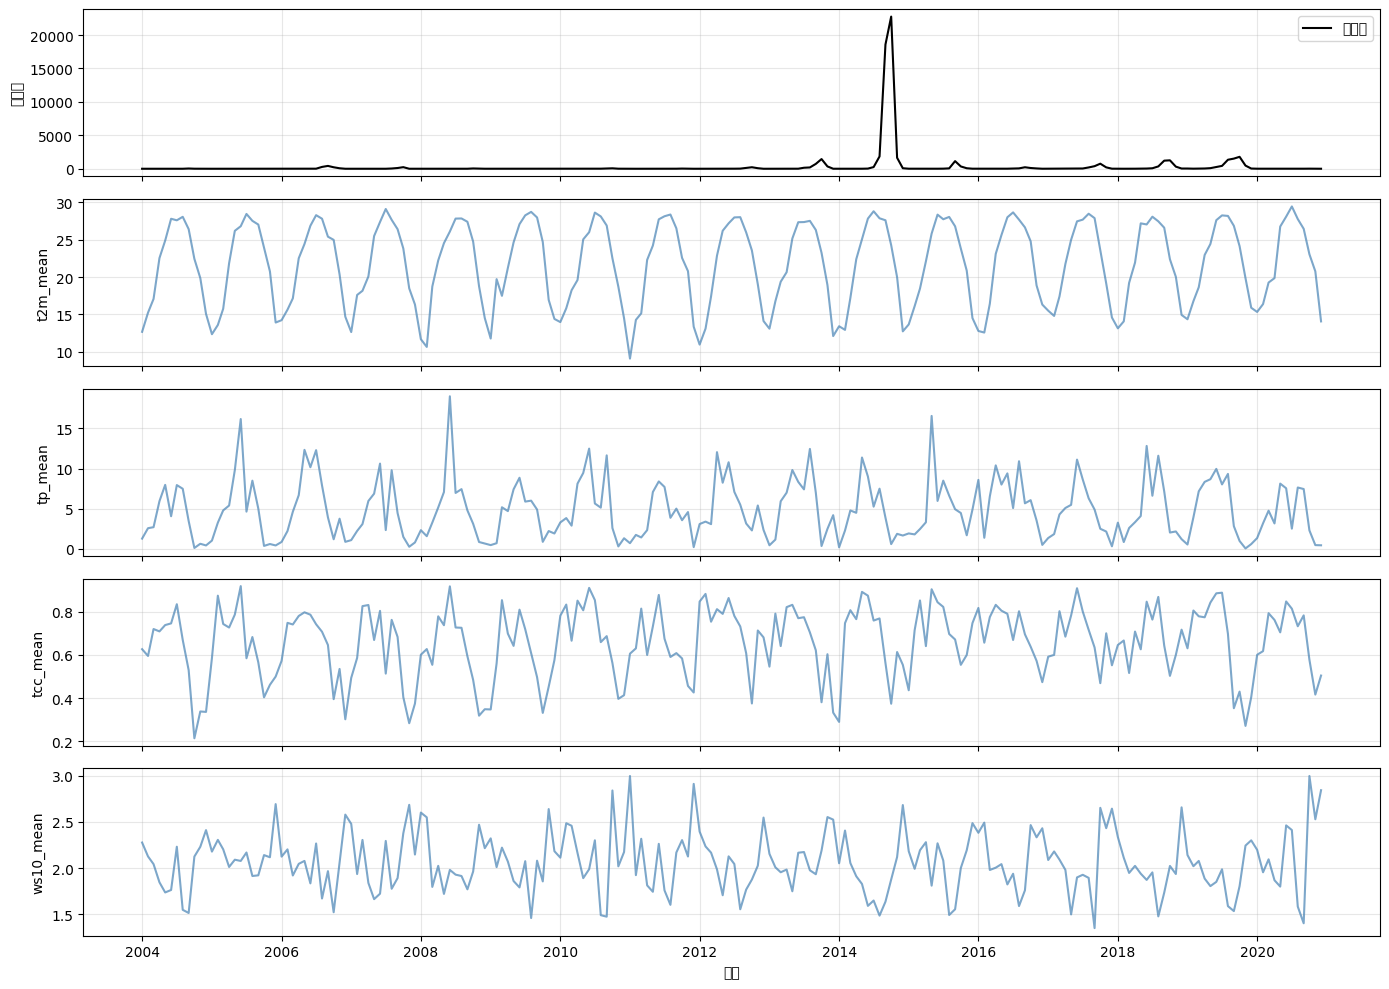

In [2]:
DF = "../data/China_vector_climate.csv"
df_raw = pd.read_csv(DF)

# 筛选广东省
df = df_raw[df_raw["province"] == "广东"].copy()
df = df.rename(columns={"Year/Month": "time"}).reset_index(drop=True)
df["time"] = pd.to_datetime(df["time"])

print(f"广东登革热: {len(df)} 个月 ({df['time'].min().date()} ~ {df['time'].max().date()})")
print(f"病例数: min={df['登革热'].min()}, max={df['登革热'].max()}, "
      f"mean={df['登革热'].mean():.0f}, nonzero={ (df['登革热']>0).sum()}/{len(df)}")

# 查看气候特征与登革热的关系
feature_cols = ["t2m_mean", "tp_mean", "tcc_mean", "ws10_mean", "skt_mean"]
fig, axes = plt.subplots(len(feature_cols), 1, figsize=(14, 10), sharex=True)
axes[0].plot(df["time"], df["登革热"], color="black", linewidth=1.5, label="登革热")
axes[0].set_ylabel("病例数"); axes[0].legend(); axes[0].grid(alpha=0.3)

for ax, col in zip(axes[1:], feature_cols):
    ax.plot(df["time"], df[col], color="steelblue", alpha=0.7)
    ax.set_ylabel(col); ax.grid(alpha=0.3)

plt.xlabel("时间"); plt.tight_layout(); plt.show()

---

## 3. 数据管道

使用气候特征（mean 值）+ 登革热历史作为输入特征。

In [ ]:
# 选择特征：登革热历史 + 气候均值
FEATURES = ["登革热"] + [c for c in df.columns if c.endswith("_mean") and c != "ssrdc_mean"]
TARGET = "登革热"
TIME_COL = "time"

print(f"特征数: {len(FEATURES)}")
print(f"特征: {FEATURES[:5]}...{FEATURES[-3:]}")

# 保存广东数据
df_gd = df[["time"] + FEATURES].copy()
df_gd.to_csv("/tmp/guangdong.csv", index=False)

bundle = ForecastPipeline(
    loader=CsvLoader(time_col=TIME_COL, target_cols=TARGET,
                     feature_cols=FEATURES),
    split=TimeSplit(train_ratio=0.7, val_ratio=0.15),
    transforms=Compose([
        StandardScaler(columns=FEATURES),              # 所有特征标准化
        DateFeatures(time_col=TIME_COL, features=["month"]),  # 月份特征
    ]),
    window=SlidingWindow(lookback=12, horizon=3),
).run("/tmp/guangdong.csv")

print(f"训练: {bundle.train_x.shape}  验证: {bundle.val_x.shape}  测试: {bundle.test_x.shape}")
print(f"实际特征数 (含变换后): {bundle.n_features}")

---

## 4. 训练模型

### 4.1 深度学习（Torch）

In [ ]:
results = {}

for name in ["MLP", "LSTM", "CNN", "CNN-LSTM", "ResNet", "TCN",
              "Transformer", "DLinear", "Autoformer", "TimesNet"]:
    try:
        model = get(name)(input_dim=bundle.n_features, lookback=12,
                          horizon=3, target_dim=1)
        r = EpiAITrainer(model=model, verbose=False,
                         optimizer_config={"max_epochs": 20}).fit(bundle)
        results[name] = r
        m = r.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  R²={m['R2']:.3f}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

### 4.2 机器学习（Sklearn）

In [ ]:
for name in ["RF", "XGB", "LGBM", "SVR", "GLM", "TabPFN"]:
    try:
        params = {
            "RF":    {"n_estimators": 200, "max_depth": 10, "random_state": 42},
            "XGB":   {"n_estimators": 200, "random_state": 42},
            "LGBM":  {"n_estimators": 200, "random_state": 42, "verbose": -1},
            "SVR":   {"kernel": "rbf", "C": 1.0},
            "GLM":   {},
            "TabPFN": {},
        }
        param_key = {"RF": "rf_params", "XGB": "xgb_params", "LGBM": "lgbm_params",
                     "SVR": "svm_params", "GLM": "glm_params", "TabPFN": "tabpfn_params"}
        model = get(name)(input_dim=bundle.n_features, lookback=12,
                          horizon=3, target_dim=1,
                          **{param_key[name]: params[name]})
        r = EpiAITrainer(model=model, verbose=False).fit(bundle)
        results[name] = r
        m = r.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  R²={m['R2']:.3f}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

### 4.3 时间序列（TimeSeries）

TS 模型不使用气候特征（纯单变量）。

In [ ]:
# 为 TS 模型构建无特征的管道
bundle_ts = ForecastPipeline(
    loader=CsvLoader(time_col=TIME_COL, target_cols=TARGET,
                     feature_cols=TARGET),       # 仅用登革热
    split=TimeSplit(train_ratio=0.7, val_ratio=0.15),
    transforms=None,                              # 无变换
    window=SlidingWindow(lookback=12, horizon=3),
).run("/tmp/guangdong.csv")

for name, kwargs in [("ETS", {"seasonal_periods": 12, "seasonal": "add", "trend": "add"}),
                      ("ARIMA", {"seasonal": True, "m": 12})]:
    try:
        model = get(name)(**kwargs)
        r = EpiAITrainer(model=model, verbose=False).fit(bundle_ts)
        results[name] = r
        m = r.metrics.iloc[0]
        print(f"  ✅ {name:10s}  MAE={m['MAE']:.0f}  R²={m['R2']:.3f}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

---

## 5. 模型对比

In [ ]:
vault = ModelVault.from_results(results, bundle)
vault.save("/tmp/guangdong_vault/")

print("\n模型对比总表（含气候特征的模型 vs 纯时间序列）：")
print(vault.summary().to_string())

best_name = vault.best("R2")
print(f"\n最佳模型: {best_name}")

---

## 6. 预测可视化

流行病学风格绘图：以黑色粗线突出实际病例轨迹，用纵向分界线划分训练/验证/测试期。

In [ ]:
# 时间轴（来自 bundle，与变换后的数据对齐）
all_time = (bundle.train_df[TIME_COL].tolist()
            + bundle.val_df[TIME_COL].tolist()
            + bundle.test_df[TIME_COL].tolist())
# 实际值（逆变换回到原始尺度）
y_all = np.concatenate([
    bundle.get_y_series_inverse("train").ravel(),
    bundle.get_y_series_inverse("val").ravel(),
    bundle.get_y_series_inverse("test").ravel(),
])

# 分界位置
n_train = len(bundle.train_df)
n_val = len(bundle.val_df)
val_start = all_time[n_train]
test_start = all_time[n_train + n_val]

fig, ax = plt.subplots(figsize=(16, 6))

# ── 背景区域标注 ──
ax.axvspan(all_time[0], val_start, alpha=0.05, color="blue", label="训练期")
ax.axvspan(val_start, test_start, alpha=0.08, color="orange", label="验证期")
ax.axvspan(test_start, all_time[-1], alpha=0.12, color="red", label="测试期")

# ── 分割线 ──
for x, label in [(val_start, "验证"), (test_start, "测试")]:
    ax.axvline(x=x, color="gray", linestyle=":", alpha=0.6)
    ax.text(x, ax.get_ylim()[1] * 0.98, label,
            ha="center", fontsize=9, color="gray",
            bbox=dict(facecolor="white", edgecolor="none", pad=1))

# ── 实际值（粗黑线，突出轨迹）─
ax.plot(all_time, y_all, "-", color="black", linewidth=2.5, alpha=0.9,
        label="实际值", zorder=5)
ax.plot(all_time, y_all, "o", color="black", markersize=3, alpha=0.6, zorder=5)

# ── 模型预测值（半透明，淡化）─
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    preds = r.predictions[:, 0, 0]
    n = len(preds)
    t = all_time[n_train + n_val:][:n]  # 测试集时段
    m = r.metrics.iloc[0]
    ax.plot(t, preds, "s--",
            label=f"{name}  (R²={m['R2']:.3f})",
            color=color, alpha=0.55, markersize=4, linewidth=1.2)

ax.legend(fontsize=9, ncol=4, loc="upper left")
ax.set_title("广东省登革热月发病数 — 多特征模型预测对比", fontsize=14, fontweight="bold")
ax.set_ylabel("病例数"); ax.set_xlabel("时间"); ax.grid(alpha=0.15, linestyle=":")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/tmp/guangdong_all_models.png", dpi=150)
plt.show()

---

## 7. 附录

In [ ]:
print("可用模型:", list_models())